In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  


In [2]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[1].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [4]:
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[0].id)


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/domain/domain_cfg
              Title: eORCA1 ERA5v1 NPD domain/domain_cfg Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean model domain and mesh mask variables.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/domain/domain_cfg
              Title: eORCA025 ERA5v1 NPD domain/domain_cfg Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 NPD global ocean model domain and mesh mask variables.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca12-era5v1/gn/domain/domain_cfg
              Title: eORCA12 ERA5v1 NPD domain/domain_cfg Icechunk repository
              D

In [5]:
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt_initial = NEMODataTree.from_datasets(datasets = datasets)

bbox = (-85.0, 0.0, 0.0, 80.0)
dt_clipped = dt_initial.clip_grid(grid="/gridT", bbox=bbox)
areas = dt_clipped.cell_area(grid="/gridT", dim="k")

# Need to geoindex after clipping
dt = dt_clipped.add_geoindex(grid="/gridT")
dt

<xarray.DataTree>
Group: /
│   Dimensions:               (time_counter: 420, axis_nbounds: 2)
│   Coordinates:
│     * time_counter          (time_counter) datetime64[ns] 3kB 1990-01-16T12:00:...
│       time_centered         (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 7kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 7kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   None
│       iperio:   False
├── Group: /gridT
│       Dimensions:                (time_counter: 420, j: 253, i: 360, k: 75,
│                                   axis_nbounds: 2)
│       Coordinates:
│         * j                      (j) int64 2kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                      (i) int64 3kB 1 2 3 4 5 6 ... 355 356 357 358 359 360
│         * k                      (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * deptht                 (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│           time_centered          (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
│         * gphit                  (j, i) float64 729kB -84.21 -84.21 -84.21 ... 0.0 0.0
│         * glamt                  (j, i) float64 729kB 73.5 74.5 75.5 ... 0.0 0.0 0.0
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/80)
│           berg_latent_heat_flux  (time_counter, j, i) float32 153MB dask.array<chunksize=(1, 253, 360), meta=np.ndarray>
│           e3t                    (time_counter, k, j, i) float32 11GB dask.array<chunksize=(1, 25, 253, 360), meta=np.ndarray>
│           empmr                  (time_counter, j, i) float32 153MB dask.array<chunksize=(1, 253, 360), meta=np.ndarray>
│           evs                    (time_counter, j, i) float32 153MB dask.array<chunksize=(1, 253, 360), meta=np.ndarray>
│           fsitherm               (time_counter, j, i) float32 153MB dask.array<chunksize=(1, 253, 360), meta=np.ndarray>
│           deptht_bounds          (k, axis_nbounds, j, i) float32 55MB dask.array<chunksize=(25, 2, 253, 360), meta=np.ndarray>
│           ...                     ...
│           e1t                    (j, i) float64 729kB dask.array<chunksize=(253, 360), meta=np.ndarray>
│           e2t                    (j, i) float64 729kB dask.array<chunksize=(253, 360), meta=np.ndarray>
│           top_level              (j, i) int32 364kB dask.array<chunksize=(253, 360), meta=np.ndarray>
│           bottom_level           (j, i) int32 364kB dask.array<chunksize=(253, 360), meta=np.ndarray>
│           tmask                  (k, j, i) float64 55MB nan nan nan ... nan nan nan
│           tmaskutil              (j, i) float64 729kB nan nan nan nan ... nan nan nan
│       Indexes:
│         ┌ gphit    NDPointIndex (SklearnGeoBallTreeAdapter)
│         └ glamt
│       Attributes:
│           nftype:   None
│           iperio:   False
├── Group: /gridU
│       Dimensions:       (j: 331, i: 360, k: 75)
│       Coordinates:
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 325 326 327 328 329 330 331
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│           gphiu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Data variables:
│           e1u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           umask         (k, j, i) float64 71MB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan
│        

In [6]:
ds_global = ((dt_initial.add_geoindex(grid="/gridT"))['/gridT']).dataset
ds = (dt['/gridT']).dataset
ds

<xarray.DatasetView> Size: 261GB
Dimensions:                (time_counter: 420, j: 253, i: 360, k: 75,
                            axis_nbounds: 2)
Coordinates:
  * time_counter           (time_counter) datetime64[ns] 3kB 1990-01-16T12:00...
  * j                      (j) int64 2kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
  * i                      (i) int64 3kB 1 2 3 4 5 6 ... 355 356 357 358 359 360
  * k                      (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
  * deptht                 (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
    time_centered          (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
  * gphit                  (j, i) float64 729kB -84.21 -84.21 -84.21 ... 0.0 0.0
  * glamt                  (j, i) float64 729kB 73.5 74.5 75.5 ... 0.0 0.0 0.0
Dimensions without coordinates: axis_nbounds
Data variables: (12/80)
    berg_latent_heat_flux  (time_counter, j, i) float32 153MB dask.array<chunksize=(1, 253, 360), meta=np.ndarray>
    e3t                    (time_counter, k, j, i) float32 11GB dask.array<chunksize=(1, 25, 253, 360), meta=np.ndarray>
    empmr                  (time_counter, j, i) float32 153MB dask.array<chunksize=(1, 253, 360), meta=np.ndarray>
    evs                    (time_counter, j, i) float32 153MB dask.array<chunksize=(1, 253, 360), meta=np.ndarray>
    fsitherm               (time_counter, j, i) float32 153MB dask.array<chunksize=(1, 253, 360), meta=np.ndarray>
    deptht_bounds          (k, axis_nbounds, j, i) float32 55MB dask.array<chunksize=(25, 2, 253, 360), meta=np.ndarray>
    ...                     ...
    e1t                    (j, i) float64 729kB dask.array<chunksize=(253, 360), meta=np.ndarray>
    e2t                    (j, i) float64 729kB dask.array<chunksize=(253, 360), meta=np.ndarray>
    top_level              (j, i) int32 364kB dask.array<chunksize=(253, 360), meta=np.ndarray>
    bottom_level           (j, i) int32 364kB dask.array<chunksize=(253, 360), meta=np.ndarray>
    tmask                  (k, j, i) float64 55MB nan nan nan ... nan nan nan
    tmaskutil              (j, i) float64 729kB nan nan nan nan ... nan nan nan
Indexes:
  ┌ gphit    NDPointIndex (SklearnGeoBallTreeAdapter)
  └ glamt
Attributes:
    nftype:   None
    iperio:   False

In [7]:
areas

<xarray.DataArray 'areacello' (j: 253, i: 360)> Size: 729kB
dask.array<mul, shape=(253, 360), dtype=float64, chunksize=(253, 360), chunktype=numpy.ndarray>
Coordinates:
  * j        (j) int64 2kB 1 2 3 4 5 6 7 8 9 ... 324 325 326 327 328 329 330 331
  * i        (i) int64 3kB 1 2 3 4 5 6 7 8 9 ... 353 354 355 356 357 358 359 360
    gphit    (j, i) float64 729kB -84.21 -84.21 -84.21 -84.21 ... 0.0 0.0 0.0
    glamt    (j, i) float64 729kB 73.5 74.5 75.5 76.5 77.5 ... 0.0 0.0 0.0 0.0

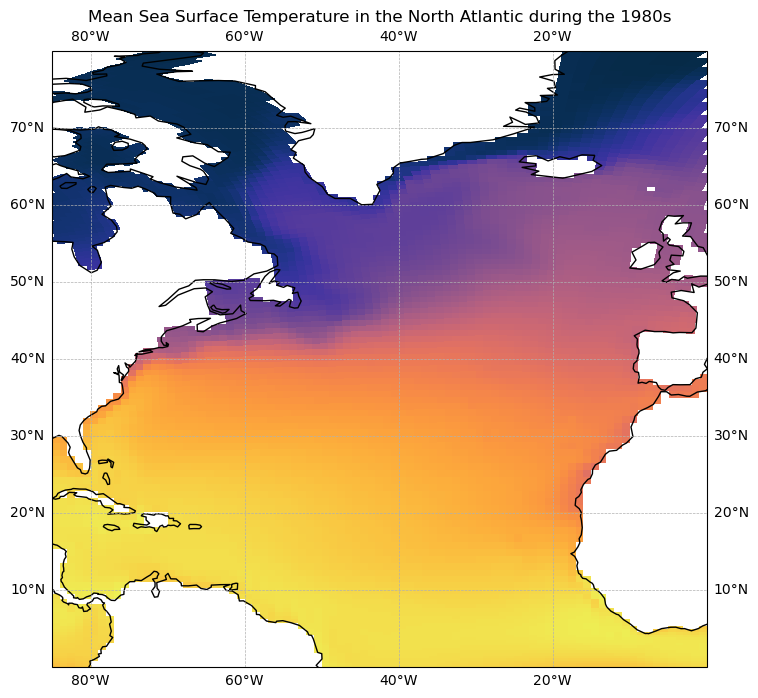

In [8]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
data = ds['tos_con'].mean(dim='time_counter')
im = ax.pcolormesh(ds['glamt'],  ds['gphit'], data, cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree(), vmin = -3, vmax = 30)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
ax.set_title('Mean Sea Surface Temperature in the North Atlantic during the 1980s')
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())

plt.show()

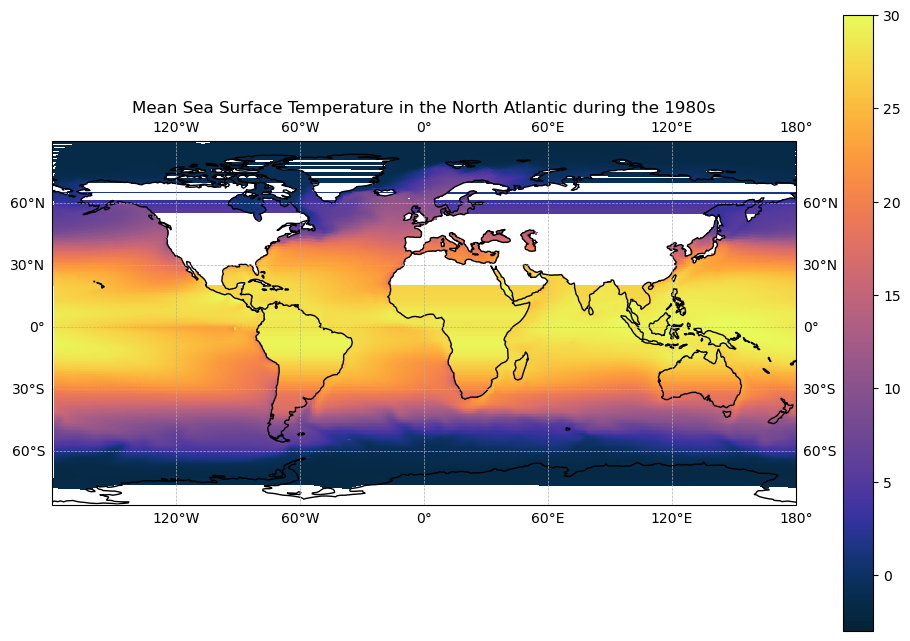

In [108]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
data = ds_global['tos_con'].mean(dim='time_counter')
im = ax.pcolormesh(ds_global['glamt'],  ds_global['gphit'], data, cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree(), vmin = -3, vmax = 30)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
ax.set_title('Mean Sea Surface Temperature in the North Atlantic during the 1980s')
plt.colorbar(im, ax=ax)

plt.show()

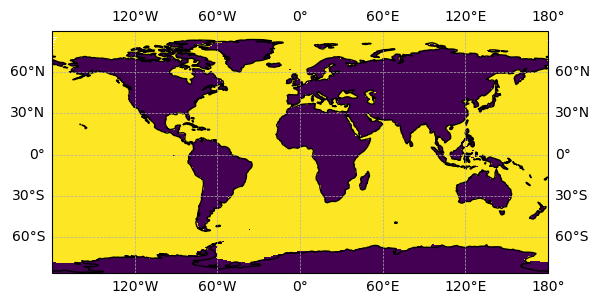

In [101]:
mask = ds_global['tos_con'].mean(dim='time_counter').notnull()

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.pcolormesh(ds_global['glamt'], ds_global['gphit'], mask, transform=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')

plt.show()